
CLINICAL DATA AALYSIS OF 10-YEAR CORONARY HEART DISEASE RISK


Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Import libraries for data handling(pandas), numerical operations(numpy), and visualization(matplotlib, seaborn).

Load the data set

In [7]:
df = pd.read_csv("heart csv.csv")
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


Loads the clinical dataset into a datagrams and displays the first few rows to verify successful loading

Verify columns

In [9]:
df.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

Checks column names to ensure that they match the expected dataset and avoid column-name errors.

Basic understanding

In [11]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


Gives a structural overviewe of the dataset.

Checking for missing values

In [12]:
df.isnull().sum()

,0
male,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


Identifies columns containing missing values, which is common in real-world clinical data.

Handling missing values(separate numerical and categorical)





In [24]:
num_cols= df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
  df[col].fillna(df[col].median(), inplace=True)

/tmp/ipython-input-2331875275.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


Separates the data into numerical and categorical values.

Median imputation

In [27]:
for col in num_cols:
  df[col].fillna(df[col].median(),
inplace=True)

/tmp/ipython-input-3772933056.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),


Fills the missing values using median imputation to reduce the effect of ouliers and maintain data integrity.

Verify missing values

In [28]:
df.isnull().sum()

,0
male,0
age,0
education,0
currentSmoker,0
cigsPerDay,0
BPMeds,0
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,0


Ensures that all the missing values have been handles successfully.

Target variable distribution

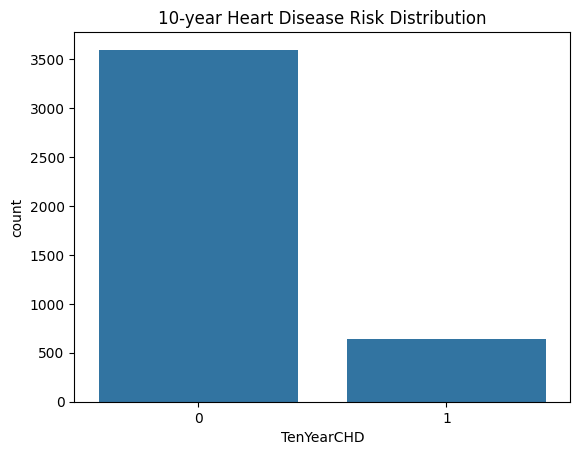

In [32]:
sns.countplot(x='TenYearCHD', data=df)
plt.title('10-year Heart Disease Risk Distribution')
plt.show()

Visualises the distribution of heart disease outcomes and highlights potential class imbalance.

Age vs Heart Disease

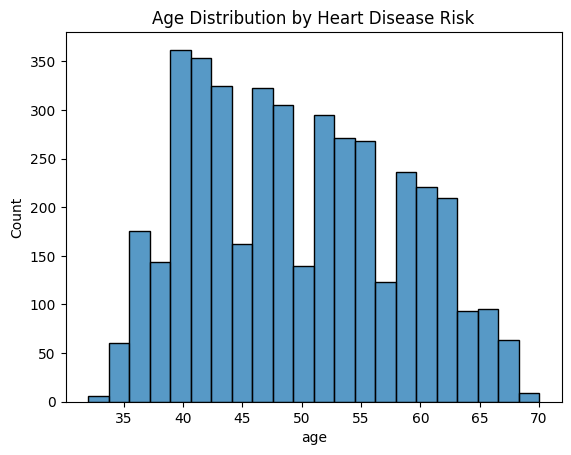

In [35]:
sns.histplot(data=df, x='age')
plt.title("Age Distribution by Heart Disease Risk")
plt.show()

Analyses how heart disease risk varies across different age groups.

Smoking effect analysis

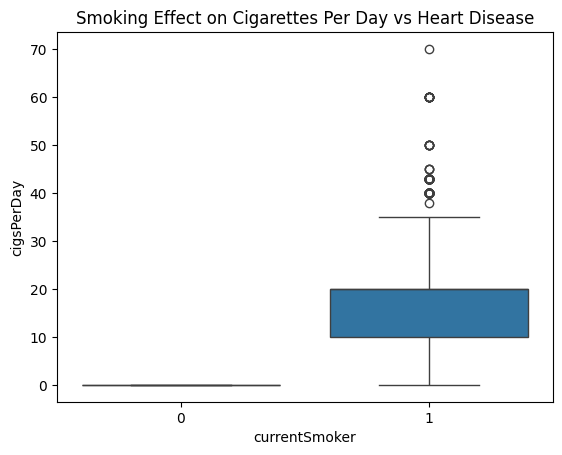

In [36]:
sns.boxplot(x='currentSmoker', y='cigsPerDay', data=df)
plt.title('Smoking Effect on Cigarettes Per Day vs Heart Disease')
plt.show()

Examines the relationship between smoking intensity and long term heart disease risk.

Blood Pressure Analysis

<function matplotlib.pyplot.show(close=None, block=None)>

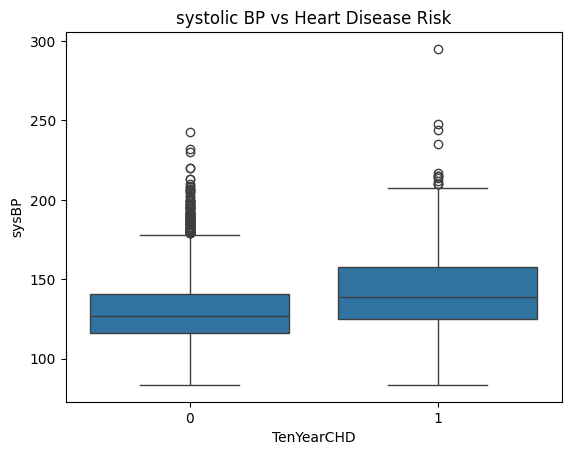

In [39]:
sns.boxplot(x='TenYearCHD', y='sysBP', data=df)
plt.title("systolic BP vs Heart Disease Risk")
plt.show

Evaluates the effect of systolic BP on heart disease ocurence.

Correlation Heatmap

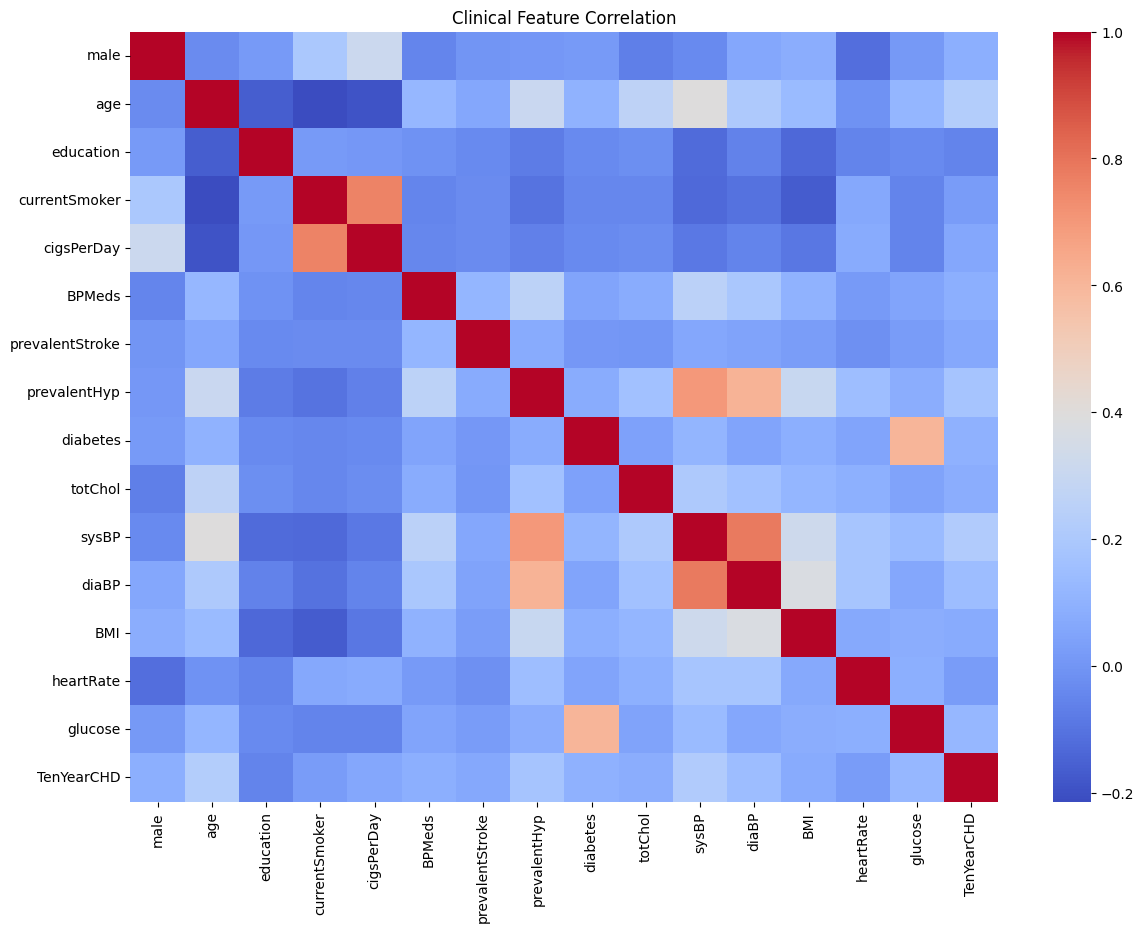

In [40]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(),
            cmap='coolwarm')
plt.title("Clinical Feature Correlation")
plt.show()

Displays correlation between clinical variables to identify strong predictors and multicollinearity.

Key Insights

1. Age, systolic BP, and cholestrol show strong association with CHD risk
2. SMoking intensity increases heart disease probability
3. Hypertension and diabetes are the major risk factors